# Initial Data exploration.

In [46]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from dataclasses import dataclass

from pprint import pprint

In [43]:
# Configs and Constants.
@dataclass
class Config:
    flight: str
    international_train: str
    international_test: str
    domestic_train: str
    domestic_test: str

BASE_DIR = Path.cwd()
DATA_FOLDER = BASE_DIR.parent.parent / "dataset" / "01a - DCT Dataset"    

In [44]:

config = Config(
    flight= DATA_FOLDER / "flight_data.xlsx",
    international_train= DATA_FOLDER / "data international_train.xlsx",
    international_test= DATA_FOLDER / "data internation_test.xlsx",
    domestic_train= DATA_FOLDER / "data domestic_train.xlsx",
    domestic_test= DATA_FOLDER / "data domestic_test.xlsx"
)

# Exploratory Analysis on flight data.

In [45]:
flight = pd.read_excel(config.flight)

In [54]:
# Columns on the dataset.
pprint(list(flight.columns.values))

['Date',
 'Departure Country Name',
 'Departure City',
 'Arrival City',
 'Airline Name',
 'Average Weekly Frequency',
 'Business Class P2P Count',
 'Business Class Seat Capacity',
 'Economy Class P2P Count',
 'Economy Class Seat Capacity',
 'First Class P2P Count',
 'First Class Seat Capacity',
 'Load Factor',
 'Total P2P',
 'Total PAX',
 'Total PAX Excluding Infant',
 'Total Seats',
 'Total Transfer',
 'Total Transit',
 'Transfer Business Class Count',
 'Transfer Economy Class Count',
 'Transfer First Class Count',
 'Transit Business Class Count',
 'Transit Economy Class Count',
 'Transit First Count',
 'Destination']


In [56]:
# Only concerned about a subset of columns for now.
subset = [
    "Date",
    "Departure Country Name",
    "Departure City",
    "Airline Name",
    "Load Factor",
    "Total P2P", # This is the column that is most relevant
    "Total Seats",
    "Total Transfer"
]

# select only a subset of columns.
df = flight[subset]

## Group-by different categories.
Understanding the size of P2P(Point-to-Point) Passengers by Date, Departure Country, City, Airline to get an understanding of size.

### Group-by Year.

In [61]:
df['Date'] = pd.to_datetime(df['Date'])
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month

In [78]:
# Groupby year
year = df.groupby('year')['Total P2P'].sum()

# Groupby Departure Country
country = df.groupby('Departure Country Name')['Total P2P'].sum().sort_values(ascending=False)

# Groupby Departure City
city = df.groupby('Departure City')['Total P2P'].sum()

# Groupby Airline
airline = df.groupby('Airline Name')['Total P2P'].sum()


In [ ]:
def plot_bar_chart(title, xlabel, ylabel, xdata, ydata, **kwargs ):

    plt.bar(xdata, ydata, color='skyblue', edgecolor='black', width=0.6, kwargs=)

    # 3. Add labels and a title for context
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    # 4. Display the plot
    plt.show()

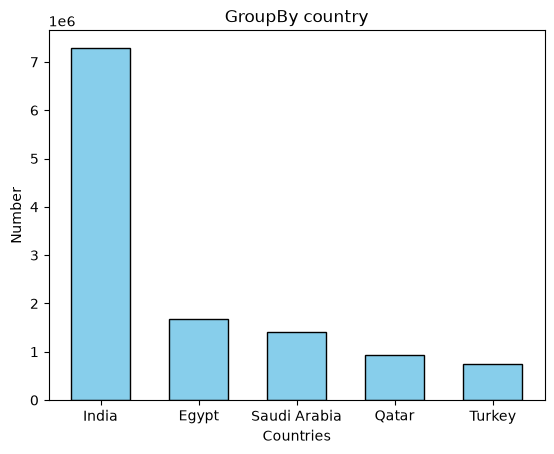

In [79]:
plot_bar_chart(
    "GroupBy country",
    "Countries",
    "Number",
    list(country.index)[:5],
    country[:5]
)

<BarContainer object of 5 artists>

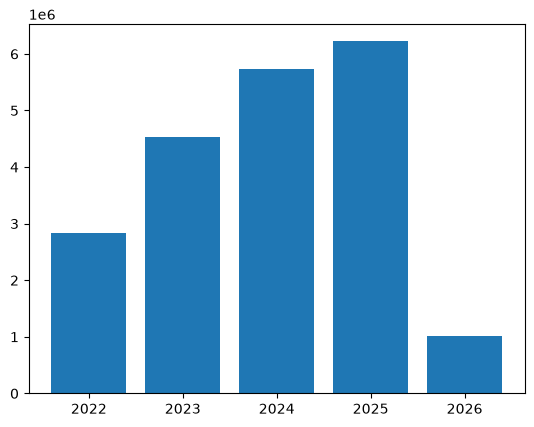

In [13]:
flight.columns

Index(['Date', 'Departure Country Name', 'Departure City', 'Arrival City',
       'Airline Name', 'Average Weekly Frequency', 'Business Class P2P Count',
       'Business Class Seat Capacity', 'Economy Class P2P Count',
       'Economy Class Seat Capacity', 'First Class P2P Count',
       'First Class Seat Capacity', 'Load Factor', 'Total P2P', 'Total PAX',
       'Total PAX Excluding Infant', 'Total Seats', 'Total Transfer',
       'Total Transit', 'Transfer Business Class Count',
       'Transfer Economy Class Count', 'Transfer First Class Count',
       'Transit Business Class Count', 'Transit Economy Class Count',
       'Transit First Count', 'Destination'],
      dtype='str')

In [16]:
# Trim it down to columns that are necessary.
trimmed_flight = flight[[
    "Date",
    "Departure Country Name",
    "Departure City",
    "Arrival City",
    "Airline Name",
    "Average Weekly Frequency",
    "Load Factor",
    "Total P2P",
]]

In [22]:
# Total P2P passengers per day.
per_day = trimmed_flight.groupby('Date', as_index=False)['Total P2P'].sum()

In [24]:
per_day['Date'] = pd.to_datetime(per_day['Date'])

In [31]:
maximum = per_day['Date'].max()
minimum = per_day['Date'].min()
print(maximum, "\n", minimum)

2026-02-28 00:00:00 
 2022-01-01 00:00:00


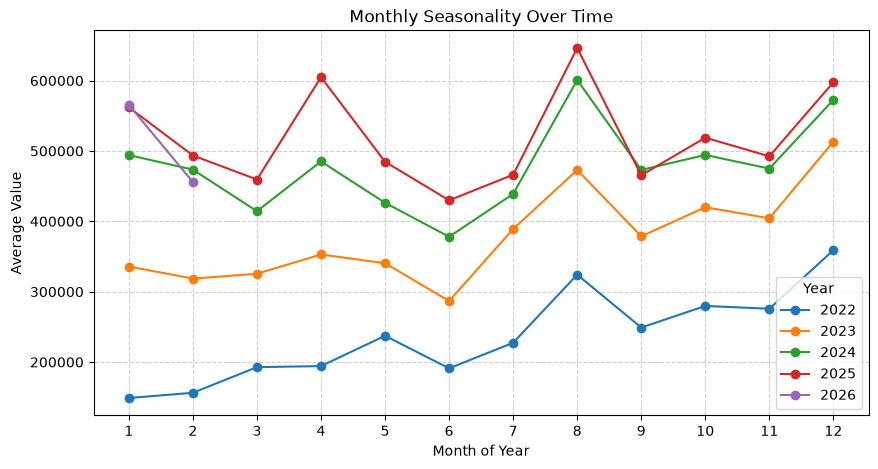

In [71]:
# Extract both Year and Month for a multi-line comparison
per_day['Year'] = per_day['Date'].dt.year
per_day['Month'] = per_day['Date'].dt.month

# Group by both dimensions and calculate the average metric
grouped = per_day.groupby(['Year', 'Month'])['Total P2P'].sum().unstack(level=0)

# Generate a multi-line time-value seasonality plot
grouped.plot(kind='line', marker='o', figsize=(10, 5))
plt.title('Monthly Seasonality Over Time')
plt.xlabel('Month of Year')
plt.ylabel('Average Value')
plt.xticks(range(1, 13)) # Ensure all 12 months show up on the X-axis
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Year')
plt.show()


In [27]:
grouped

Year,2022,2023,2024,2025,2026
Month,,,,,
1,148912.0,10830.677419,15940.161290,18130.129032,18242.580645
2,156318.0,11377.785714,16324.482759,17626.178571,16276.892857
3,192749.0,10500.806452,13368.064516,14820.451613,NaN
4,194267.0,11761.900000,16170.266667,20162.766667,NaN
5,237298.0,10982.225806,13752.000000,15633.000000,NaN
6,191058.0,9557.700000,12601.233333,14328.066667,NaN
7,227414.0,12551.129032,14159.000000,15040.645161,NaN
8,324176.0,15258.806452,19382.838710,20849.419355,NaN
9,249026.0,12624.000000,15767.133333,15516.300000,NaN
